# Customer Churn Analysis - Team 1
## Exploratory Data Analysis (EDA)

Run after Data Preparation. Uses the cleaned dataset (post duplicate removal and
consistency fixes) with readable category labels, so charts are easy to interpret.

## 0. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
palette = {"Yes": "#E4572E", "No": "#4C6EF5"}

df = pd.read_csv("Dataset_ATS_v2.csv")

# Re-apply the same integrity fixes as the Data Preparation stage
df = df.drop_duplicates().reset_index(drop=True)
inconsistent_mask = (df["PhoneService"] == "No") & (df["MultipleLines"] == "Yes")
df.loc[inconsistent_mask, "MultipleLines"] = "No"

print(df.shape)
df.head()

(6741, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


## 1. Overall churn rate

Overall churn rate: 26.6%


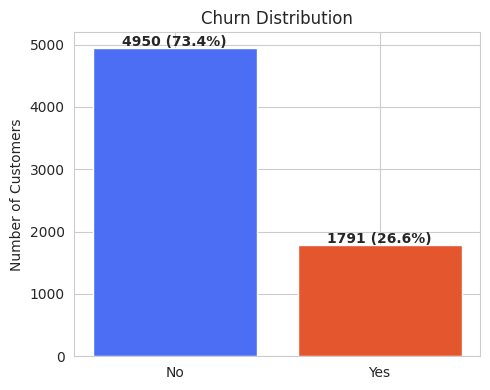

In [2]:
churn_rate = (df["Churn"] == "Yes").mean()
print(f"Overall churn rate: {churn_rate:.1%}")

fig, ax = plt.subplots(figsize=(5,4))
counts = df["Churn"].value_counts()
ax.bar(counts.index, counts.values, color=[palette.get(x,"#888") for x in counts.index])
for i,v in enumerate(counts.values):
    ax.text(i, v+30, f"{v} ({v/len(df):.1%})", ha="center", fontweight="bold")
ax.set_title("Churn Distribution")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced -- about 27% of customers churned vs 73% who
didn't. This matters for later modelling: accuracy alone would be a misleading metric, and
resampling or class weighting may be worth considering downstream.

## 2. Churn rate by contract type

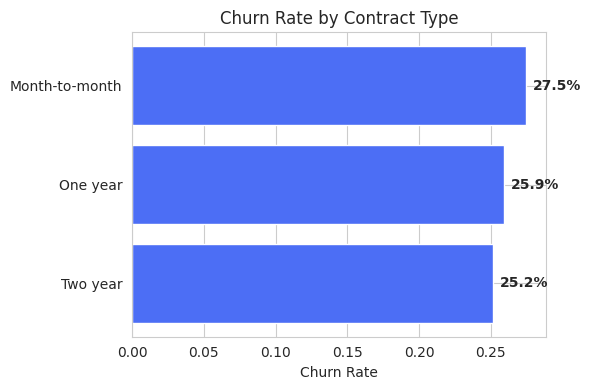

Contract
Two year          0.251668
One year          0.259208
Month-to-month    0.274569
Name: Churn, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
rate = df.groupby("Contract")["Churn"].apply(lambda x: (x=="Yes").mean()).sort_values()
ax.barh(rate.index, rate.values, color="#4C6EF5")
for i,v in enumerate(rate.values):
    ax.text(v+0.005, i, f"{v:.1%}", va="center", fontweight="bold")
ax.set_xlabel("Churn Rate")
ax.set_title("Churn Rate by Contract Type")
plt.tight_layout()
plt.show()

rate

**Observation:** Month-to-month customers churn slightly more than one/two-year contract
customers, though the gap in this dataset is modest (a few percentage points) rather than
dramatic.

## 3. Tenure vs churn

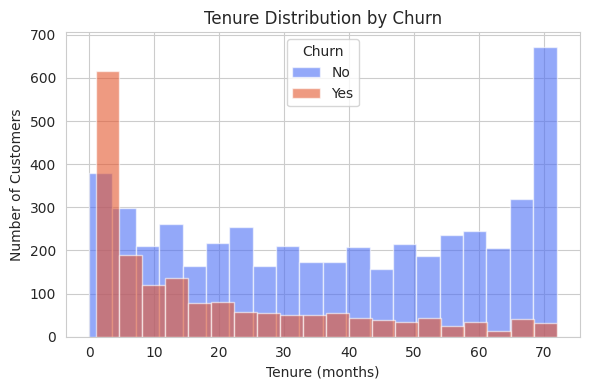

Correlation between tenure and churn (encoded): -0.3558053812385958


In [4]:
fig, ax = plt.subplots(figsize=(6,4))
for label in ["No","Yes"]:
    ax.hist(df[df.Churn==label]["tenure"], bins=20, alpha=0.6, label=label, color=palette[label])
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.set_title("Tenure Distribution by Churn")
ax.legend(title="Churn")
plt.tight_layout()
plt.show()

print("Correlation between tenure and churn (encoded):",
      df.assign(ChurnBin=(df.Churn=="Yes").astype(int))[["tenure","ChurnBin"]].corr().iloc[0,1])

**Observation:** This is the strongest signal in the dataset -- churned customers skew
heavily toward low tenure. Correlation between tenure and churn is around -0.36, meaning
newer customers are considerably more likely to churn than long-tenured ones.

## 4. Monthly charges vs churn

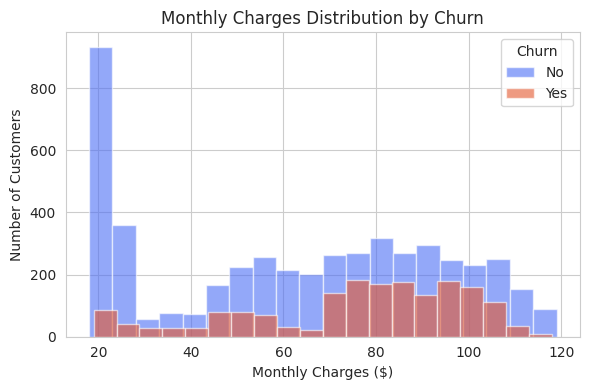

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
for label in ["No","Yes"]:
    ax.hist(df[df.Churn==label]["MonthlyCharges"], bins=20, alpha=0.6, label=label, color=palette[label])
ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Number of Customers")
ax.set_title("Monthly Charges Distribution by Churn")
ax.legend(title="Churn")
plt.tight_layout()
plt.show()

**Observation:** Churned customers tend to have somewhat higher monthly charges. Weaker
signal than tenure but still a mild positive relationship (correlation ~0.19).

## 5. Churn rate by internet service

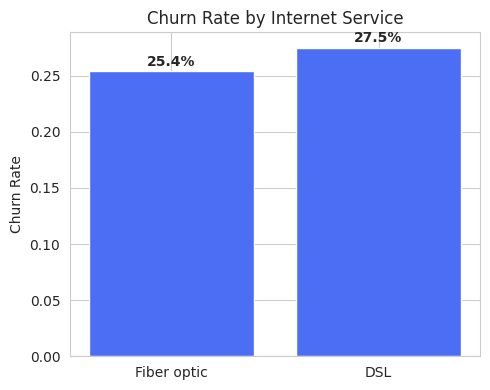

In [6]:
fig, ax = plt.subplots(figsize=(5,4))
rate = df.groupby("InternetService")["Churn"].apply(lambda x: (x=="Yes").mean()).sort_values()
ax.bar(rate.index, rate.values, color="#4C6EF5")
for i,v in enumerate(rate.values):
    ax.text(i, v+0.005, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Internet Service")
plt.tight_layout()
plt.show()

## 6. Churn rate by senior citizen / dependents

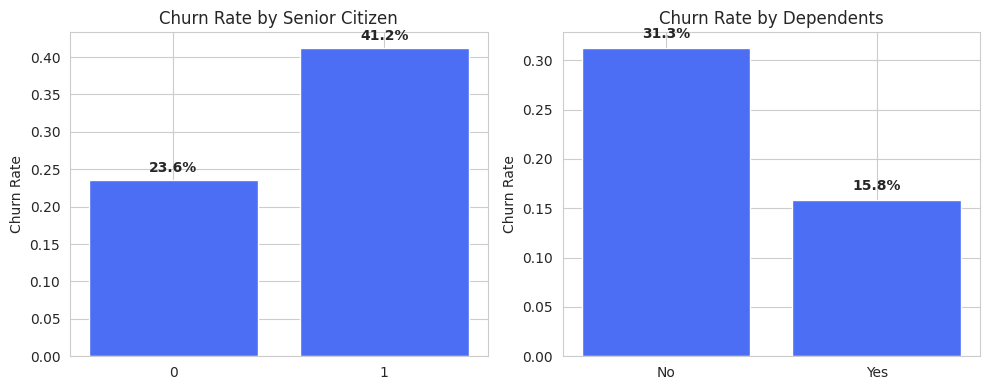

In [7]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, col, title in zip(axes, ["SeniorCitizen","Dependents"], ["Senior Citizen","Dependents"]):
    g = df.groupby(col)["Churn"].apply(lambda x: (x=="Yes").mean())
    xvals = [str(i) for i in g.index]
    ax.bar(xvals, g.values, color="#4C6EF5")
    for i,v in enumerate(g.values):
        ax.text(i, v+0.01, f"{v:.1%}", ha="center", fontweight="bold")
    ax.set_title(f"Churn Rate by {title}")
    ax.set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()

**Observation:** Senior citizens churn at a noticeably higher rate than non-seniors.
Customers without dependents also churn more than those with dependents.

## 7. Correlation heatmap (encoded features)

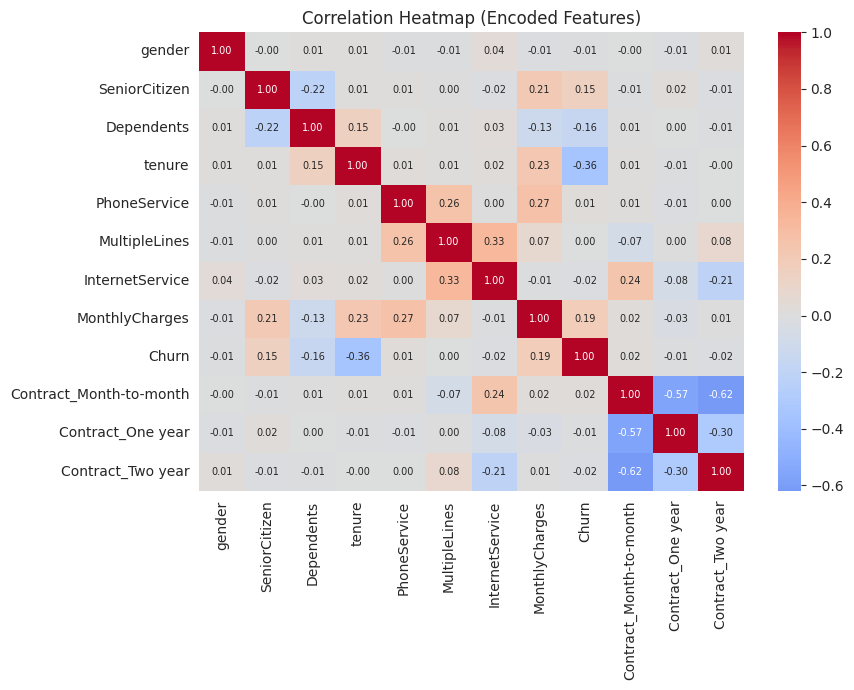

In [8]:
enc = df.copy()
for col in ["Dependents","PhoneService","MultipleLines","Churn"]:
    enc[col] = enc[col].map({"Yes":1,"No":0})
enc["gender"] = enc["gender"].map({"Male":1,"Female":0})
enc["InternetService"] = enc["InternetService"].map({"DSL":0,"Fiber optic":1})
enc = pd.get_dummies(enc, columns=["Contract"], drop_first=False)
for c in enc.columns:
    if enc[c].dtype == bool:
        enc[c] = enc[c].astype(int)

corr = enc.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size":7})
ax.set_title("Correlation Heatmap (Encoded Features)")
plt.tight_layout()
plt.show()

## Summary of Key Findings

1. **Class imbalance:** ~27% churn rate overall -- worth factoring into model evaluation
   (e.g. use F1/recall alongside accuracy, consider class weighting).
2. **Tenure is the strongest predictor:** new customers churn far more than long-tenured
   ones (correlation ~ -0.36). Retention efforts are likely most valuable in a customer's
   first several months.
3. **Monthly charges** show a mild positive relationship with churn -- pricier plans churn
   slightly more.
4. **Contract type and internet service** show only modest differences in this dataset --
   weaker signals than tenure/charges, but still directionally consistent with expectations
   (month-to-month and DSL customers churn a bit more).
5. **Senior citizens** and customers **without dependents** churn at higher rates.

These findings feed directly into Stage 2's clustering analysis -- tenure and monthly
charges in particular look like strong candidate features for segmenting customers into
meaningful churn-risk groups.